In [1]:
!pip install kagglehub -q

import kagglehub
path = kagglehub.dataset_download("aviral342/social-media-engagement-dataset")
print("Dataset downloaded to:", path)

import os
print(os.listdir(path))

100%|██████████| 184k/184k [00:00<00:00, 51.5MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/aviral342/social-media-engagement-dataset/versions/1
['social_media_engagement_dataset.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# adjust filename once you see the output of Cell 1
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(df.shape)
df.head()

(5000, 20)


,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


In [3]:
insta = df[df['Platform'] == 'Instagram'].copy()
print(f"Instagram posts: {len(insta)}")

# Check for missing values
print(insta.isnull().sum())

# Convert timestamp
insta['Timestamp'] = pd.to_datetime(insta['Timestamp'])
insta['Hour'] = insta['Timestamp'].dt.hour
insta['DayOfWeek'] = insta['Timestamp'].dt.day_name()

insta.describe()

Instagram posts: 1283
Post_ID            0
Timestamp          0
Platform           0
Content_Type       0
Category           0
Likes              0
Comments           0
Shares             0
Views              0
Saves              0
Follower_Count     0
Engagement_Rate    0
Hour_of_Day        0
Day_of_Week        0
Hashtag_Count      0
Content_Length     0
Sentiment          0
Influencer_Tier    0
Has_Media          0
Is_Verified        0
dtype: int64


,Timestamp,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Hashtag_Count,Content_Length,Hour
count,1283,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000
mean,2025-01-02 01:45:49.805144064,4943.328137,241.158223,150.958691,24898.541699,510.491037,246156.945440,8.124170,11.488698,14.477786,838.752143,11.488698
min,2024-01-01 01:42:00,51.000000,5.000000,2.000000,551.000000,10.000000,659.000000,0.060000,0.000000,0.000000,15.000000,0.000000
25%,2024-06-26 16:40:00,2429.000000,116.000000,75.000000,12828.000000,269.500000,120058.000000,1.190000,5.000000,7.000000,332.500000,5.000000
50%,2025-01-02 03:55:00,4991.000000,240.000000,148.000000,23930.000000,517.000000,242044.000000,2.120000,12.000000,15.000000,688.000000,12.000000
75%,2025-07-07 04:13:00,7454.500000,357.000000,229.500000,37346.000000,764.500000,369725.000000,4.170000,18.000000,22.000000,1320.000000,18.000000
max,2025-12-31 21:56:00,9998.000000,499.000000,299.000000,49983.000000,999.000000,499770.000000,1092.180000,23.000000,29.000000,1999.000000,23.000000
std,NaN,2860.619947,141.106373,87.267627,14158.414707,288.342967,144154.072214,44.815622,6.962155,8.672500,587.551216,6.962155


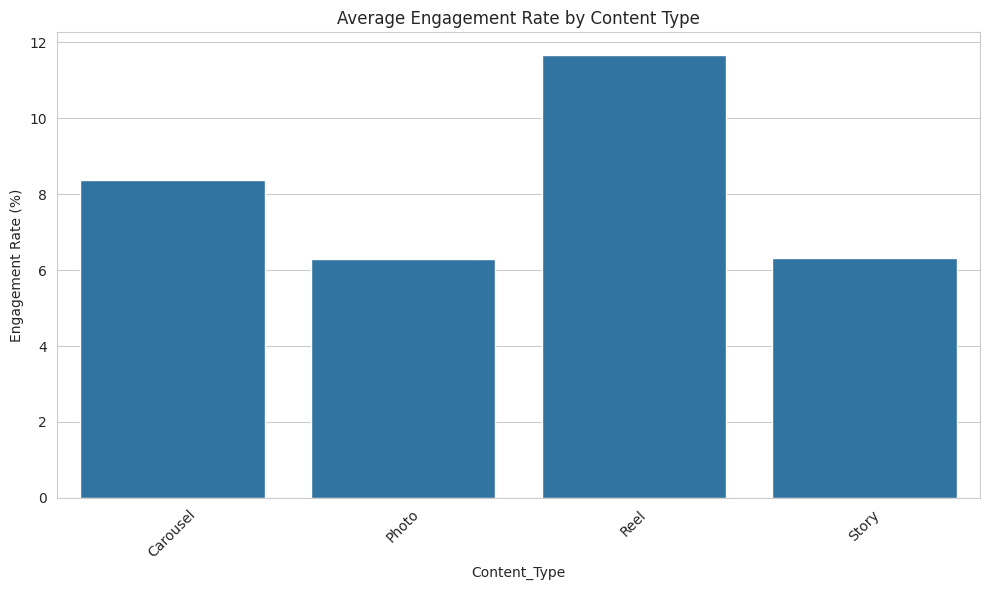

In [13]:
fig, ax = plt.subplots()
sns.barplot(data=insta, x='Content_Type', y='Engagement_Rate', ax=ax, errorbar=None)
ax.set_title('Average Engagement Rate by Content Type')
ax.set_ylabel('Engagement Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_name.png', dpi=150, bbox_inches='tight')
plt.show()

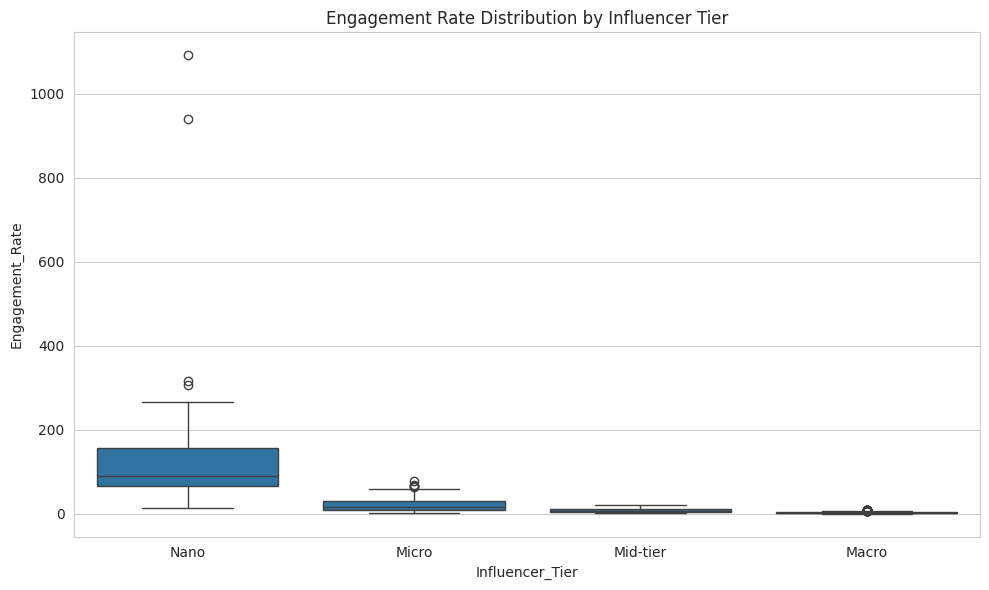

In [12]:
tier_order = ['Nano', 'Micro', 'Mid-tier', 'Macro']
fig, ax = plt.subplots()
sns.boxplot(data=insta, x='Influencer_Tier', y='Engagement_Rate', order=tier_order, ax=ax)
ax.set_title('Engagement Rate Distribution by Influencer Tier')
plt.tight_layout()
plt.savefig('chart_name.png', dpi=150, bbox_inches='tight')
plt.show()

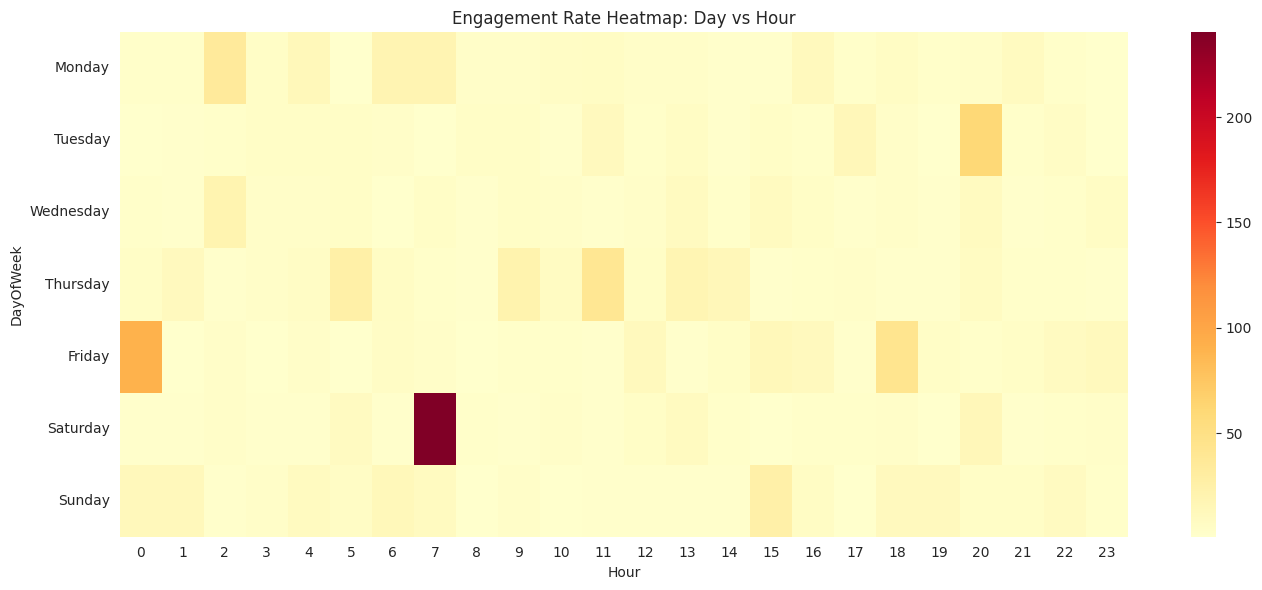

In [11]:
pivot = insta.pivot_table(values='Engagement_Rate', index='DayOfWeek', columns='Hour', aggfunc='mean')
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(day_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title('Engagement Rate Heatmap: Day vs Hour')
plt.tight_layout()
plt.savefig('chart_name.png', dpi=150, bbox_inches='tight')
plt.show()

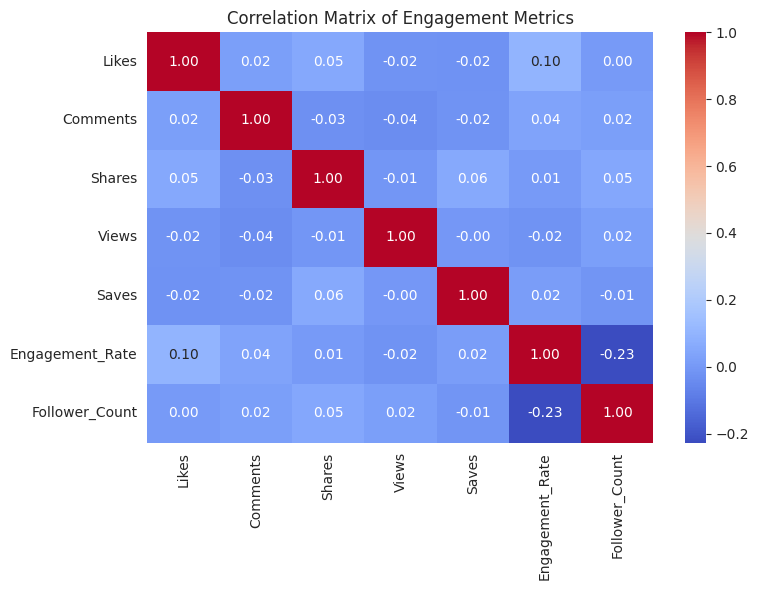

In [10]:
numeric_cols = ['Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Engagement_Rate', 'Follower_Count']
corr = insta[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Engagement Metrics')
plt.tight_layout()
plt.savefig('chart_name.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from scipy import stats

verified = insta[insta['Is_Verified'] == True]['Engagement_Rate']
not_verified = insta[insta['Is_Verified'] == False]['Engagement_Rate']

t_stat, p_value = stats.ttest_ind(verified, not_verified, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Statistically significant difference in engagement between verified and non-verified accounts.")
else:
    print("No statistically significant difference found.")

T-statistic: 0.541, P-value: 0.5887
No statistically significant difference found.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

features = ['Content_Type', 'Category', 'Follower_Count', 'Is_Verified', 'Hour']
X = insta[features]
y = insta['Engagement_Rate']

categorical = ['Content_Type', 'Category']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical)],
    remainder='passthrough'
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print(f"R² Score: {r2_score(y_test, preds):.3f}")
print(f"MAE: {mean_absolute_error(y_test, preds):.3f}")

R² Score: 0.132
MAE: 11.565


## Key Insights

1. **Content type matters**: Reels drive ~11.7% average engagement rate, roughly 85% higher
   than Photos or Stories (~6.3%) and notably ahead of Carousels (~8.4%).

2. **Smaller accounts, stronger engagement**: Nano-influencers show dramatically higher engagement
   rates than Micro, Mid-tier, and Macro accounts, and Follower_Count is the single strongest
   correlate of Engagement_Rate in the dataset (r = -0.23)  meaning reach and engagement rate
   trade off against each other.

3. **Verification has no effect**: A t-test comparing verified vs non-verified accounts found no
   statistically significant difference in engagement rate (p = 0.589). Status badges don't
   move the needle audience size does.

4. **Posting time is mostly flat**: Outside of a few isolated spikes (likely single high-performing
   posts rather than a reliable pattern), engagement rate doesn't vary strongly by day or hour
   in this dataset.

5. **Engagement rate is hard to predict from these features alone**: A linear regression using
   content type, category, follower count, verification, and hour explained only ~13% of the
   variance in engagement rate (R² = 0.132, MAE = 11.57). This suggests engagement is driven by
   factors not captured here (caption quality, visual content, audience relationship) and that
   the relationship between follower count and engagement is likely non-linear, which a tree-based
   model (e.g. Random Forest) might capture better.

## Recommendations
- Prioritize Reels over static photo/story content to lift engagement rate.
- Don't assume verification or "influencer status" alone signals engagement value —
  evaluate creators on demonstrated engagement rate, especially smaller accounts.
- Treat posting-time optimization as low-priority relative to content format and
  audience-size targeting, given the flat pattern observed here.